По историческим данным о прокате велосипедов и погодным условиям необходимо оценить спрос на прокат
велосипедов.

# Библиотеки

In [1]:
from sklearn import model_selection, linear_model, metrics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor


# Загрузка данных

Загрузите датасет с помощью функции pandas.read_csv в переменную df

In [2]:
df = pd.read_csv('bike_sharing_demand.csv')

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# df = pd.read_csv('/content/sample_data/bike.csv')

Выведите первые 5 строчек, чтобы убедиться в корректном считывании данных:

In [3]:
df.head(5)

,datetime,season,holiday,weather,temp,atemp,humidity,windspeed,count
0,2011-01-01 0:00:00,1,0,1,9.84,14.395,81,0.0,16
1,2011-01-01 1:00:00,1,0,1,9.02,13.635,80,0.0,40
2,2011-01-01 2:00:00,1,0,1,9.02,13.635,80,0.0,32
3,2011-01-01 3:00:00,1,0,1,9.84,14.395,75,0.0,13
4,2011-01-01 4:00:00,1,0,1,9.84,14.395,75,0.0,1


Краткое описание признаков:<br>
datetime: дата и время с точностью до часа<br>
season: время года (1 - весна, 2 - лето, 3 - осень, 4 - зима)<br>
holiday: день отдыха (праздник, выходной) или нет (0 - не день отдыха, 1 - день отдыха)<br>
weather: оценка благоприятности погоды от 1 (чистый, ясный день) до 4 (ливень, туман)<br>
temp: температура в градусах Цельсия<br>
atemp: температура по ощущениям в градусах Цельсия<br>
humidity: влажность<br>
windspeed(mph): скорость ветра в милях в час<br>
count: количество арендованных велосипедов (это целевой признак, его мы будем предсказывать)<br>

Выведите размер набора данных: сколько в нем строк и столбцов

In [4]:
df.shape

(10886, 9)

В наборе данных 10886 строк и 9 столбцов.

Определите, присутствют ли в наборе пропущенные значения. Если они будут, то придумайте как их устранить и
устраните.

In [5]:
df.isnull().sum()

datetime     0
season       0
holiday      0
weather      0
temp         0
atemp        0
humidity     0
windspeed    0
count        0
dtype: int64

В наборе нет пропущенных значений.

# Предобработка данных

### Типы признаков

Выведите информацию о типах признаков.

In [6]:
df.dtypes

datetime      object
season         int64
holiday        int64
weather        int64
temp         float64
atemp        float64
humidity       int64
windspeed    float64
count          int64
dtype: object

Преобразуйте даные в столбце datatime к типу данных datetime из библиотеки pandas (pd.datetime)

In [8]:
from datetime import datetime
df['datetime'] = pd.to_datetime(df['datetime'])
df.dtypes

datetime     datetime64[ns]
season                int64
holiday               int64
weather               int64
temp                float64
atemp               float64
humidity              int64
windspeed           float64
count                 int64
dtype: object

Сделайте два дополнительных столбца в наборе, в одном из них разместите месяц события, в другом час.

In [10]:
df['month'] = df['datetime'].dt.month
df['hour'] = df['datetime'].dt.hour
df

,datetime,season,holiday,weather,temp,atemp,humidity,windspeed,count,month,hour
0,2011-01-01 00:00:00,1,0,1,9.84,14.395,81,0.0000,16,1,0
1,2011-01-01 01:00:00,1,0,1,9.02,13.635,80,0.0000,40,1,1
2,2011-01-01 02:00:00,1,0,1,9.02,13.635,80,0.0000,32,1,2
3,2011-01-01 03:00:00,1,0,1,9.84,14.395,75,0.0000,13,1,3
4,2011-01-01 04:00:00,1,0,1,9.84,14.395,75,0.0000,1,1,4
...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,15.58,19.695,50,26.0027,336,12,19
10882,2012-12-19 20:00:00,4,0,1,14.76,17.425,57,15.0013,241,12,20
10883,2012-12-19 21:00:00,4,0,1,13.94,15.910,61,15.0013,168,12,21
10884,2012-12-19 22:00:00,4,0,1,13.94,17.425,61,6.1932,129,12,22


Столбец datetime из набора удалите

In [11]:
df = df.drop('datetime',axis=1)

Выведите 10 первых записей преобразованного набора

In [12]:
df.head(10)

,season,holiday,weather,temp,atemp,humidity,windspeed,count,month,hour
0,1,0,1,9.84,14.395,81,0.0000,16,1,0
1,1,0,1,9.02,13.635,80,0.0000,40,1,1
2,1,0,1,9.02,13.635,80,0.0000,32,1,2
3,1,0,1,9.84,14.395,75,0.0000,13,1,3
4,1,0,1,9.84,14.395,75,0.0000,1,1,4
5,1,0,2,9.84,12.880,75,6.1932,1,1,5
6,1,0,1,9.02,13.635,80,0.0000,2,1,6
7,1,0,1,8.20,12.880,86,0.0000,3,1,7
8,1,0,1,9.84,14.395,75,0.0000,8,1,8
9,1,0,1,13.12,17.425,76,0.0000,14,1,9


### Обучение и отложенный тест

Выделите из набора отложенную выборку из последних 1000 записей набора

In [13]:
train = df.iloc [:-1000, :]
test = df.iloc [-1000:, :]

Проконтроллируйте размеры полученных обучающей и отложенной выборки

In [14]:
test.shape

(1000, 10)

In [15]:
train.shape

(9886, 10)

### Данные и целевая функция

Разделите данные в обучающей и в тестовой выборке, выделив отдельно значения целевой функции.

In [16]:
x_train = train.drop('count',axis=1)
y_train = train['count']

In [17]:
x_test = test.drop('count',axis=1)
y_test = test['count']

### Целевая функция на обучающей выборке и на отложенном тесте

Постройте две гистограммы для значения целевой функции для обучающей и отложенной выборки

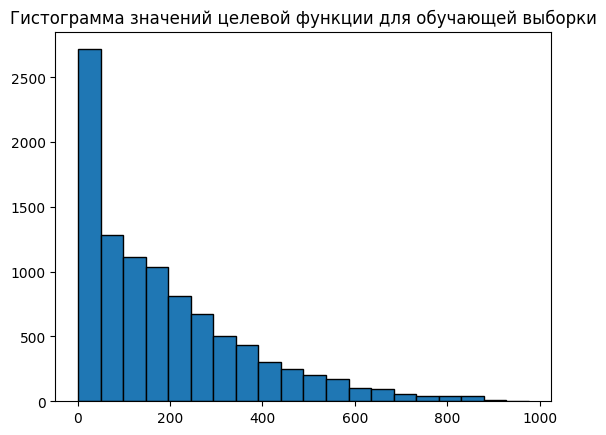

In [18]:
plt.hist(y_train, bins=20, edgecolor='black');
plt.title('Гистограмма значений целевой функции для обучающей выборки');

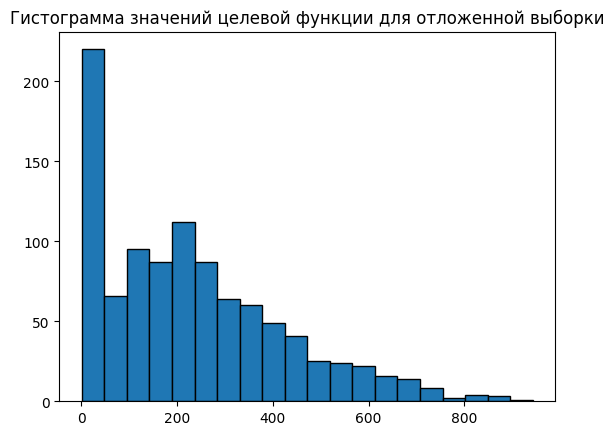

In [19]:
plt.hist(y_test, bins=20, edgecolor='black');
plt.title('Гистограмма значений целевой функции для отложенной выборки');

# Построение моделей машинного обучения

### Линейные модели

Используйте стохастический градиентный спуск (SGDRegressor) для решения задачи регрессии и вычислите
среднюю абсолютную ошибку предсказаний, а также выведите полученные коэффициенты построенной модели
регрессии

In [21]:
SGD = SGDRegressor(random_state=42)
SGD = SGD.fit(x_train,y_train)

train_MAE = mean_absolute_error(y_train, SGD.predict(x_train))
test_MAE = mean_absolute_error(y_test, SGD.predict(x_test))
print('Cредняя абсолютная ошибка для обучающей выборки:', train_MAE)
print('Cредняя абсолютная ошибка для отложенной выборки:', test_MAE)

Cредняя абсолютная ошибка для обучающей выборки: 246903387859.67157
Cредняя абсолютная ошибка для отложенной выборки: 251423521142.5221


In [ ]:
sorted(list(zip(x_train.columns, SGD.coef_)),
       key=lambda x: abs(x[1]))

[('month', 8043676.489152583),
 ('atemp', -100835230.65885381),
 ('holiday', 1227734846.0088656),
 ('temp', -1499678307.911477),
 ('hour', 1529285370.646108),
 ('windspeed', -2038410687.0341587),
 ('season', -2627386065.2048984),
 ('humidity', -3325860709.521358),
 ('weather', 6103912227.676961)]

Cредние абсолютные ошибки получилтсь очень большими. Необходимо масштабировать данные для того, чтобы размерности переменных были сопоставимы.

### Scaling

Проведите масштабирование набора данных. Используйте StandardScaler

In [23]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
x_train_scaled

array([[-1.27897814, -0.17291312, -0.6459162 , ..., -1.57200066,
        -1.55971876, -1.6683207 ],
       [-1.27897814, -0.17291312, -0.6459162 , ..., -1.57200066,
        -1.55971876, -1.52373895],
       [-1.27897814, -0.17291312, -0.6459162 , ..., -1.57200066,
        -1.55971876, -1.3791572 ],
       ...,
       [ 1.55155195, -0.17291312, -0.6459162 , ..., -0.20825756,
         1.23027756, -1.08999371],
       [ 1.55155195, -0.17291312, -0.6459162 , ...,  0.49745217,
         1.23027756, -0.94541196],
       [ 1.55155195, -0.17291312, -0.6459162 , ..., -0.20825756,
         1.23027756, -0.80083021]])

Обучите модель из предыдущего раздела на масштабированных данных. Оцените качество получаемых моделью
предсказаний, используя метрику MAE

In [24]:
SGD = SGDRegressor(random_state=42,)
SGD = SGD.fit(x_train_scaled,y_train)

train_MAE = mean_absolute_error(y_train, SGD.predict(x_train_scaled))
test_MAE = mean_absolute_error(y_test, SGD.predict(x_test_scaled))
print('Cредняя абсолютная ошибка для обучающей выборки:', train_MAE)
print('Cредняя абсолютная ошибка для отложенной выборки:', test_MAE)

Cредняя абсолютная ошибка для обучающей выборки: 105.42475136175209
Cредняя абсолютная ошибка для отложенной выборки: 121.77988316224796


Выведите предсказанные и истинные значения знанчения целевой функции для первых 10 элементов набора

In [25]:
y_pred = SGD.predict(x_test_scaled)
pred = pd.DataFrame({"y_real":y_test, "y_pred":y_pred})
pred.head(10)

,y_real,y_pred
9886,525,129.445512
9887,835,152.588402
9888,355,191.743582
9889,222,221.382332
9890,228,237.654681
9891,325,244.863964
9892,328,256.019700
9893,308,282.441720
9894,346,286.365235
9895,446,297.494555


Выведите коэффициенты линейной регрессии для данной модели

In [26]:
sorted(list(zip(x_train.columns, SGD.coef_)),
       key=lambda x: abs(x[1]))

[('holiday', -1.4838492311686762),
 ('windspeed', 1.9602986338768877),
 ('weather', -2.9214983864284823),
 ('season', -7.790423494099049),
 ('month', 20.977694057295135),
 ('temp', 29.944059599009435),
 ('atemp', 32.12836797929172),
 ('humidity', -44.215540365942246),
 ('hour', 50.40305485901778)]

# Подбор параметров

Выполните подбор параметров по сетке для SGDRegressor. Обязательные параметры для подбора: способ
регуляризации и коэффициент регуляризации. Для оценки качества модели все также используйте MAE и при
кросс-валидации используйте метод KFold, в котором разбиение набора данных происходит на 4 части (4-Fold
cross validation)

In [27]:
param_grid = {
    'penalty': ['l2', 'l1', 'elasticnet'],
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

scaled_estimator = SGDRegressor(random_state=42)
# НЕ БЫЛО УКАЗАНО scoring
scaled_optimizer = GridSearchCV(scaled_estimator, param_grid, cv=4, scoring="neg_mean_absolute_error")
scaled_optimizer.fit(x_train_scaled, y_train)

GridSearchCV(cv=4, estimator=SGDRegressor(random_state=42),
             param_grid={'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000],
                         'penalty': ['l2', 'l1', 'elasticnet']},
             scoring='neg_mean_absolute_error')

In [28]:
train_MAE = mean_absolute_error(y_train, scaled_optimizer.predict(x_train_scaled))
test_MAE = mean_absolute_error(y_test, scaled_optimizer.predict(x_test_scaled))
print('Cредняя абсолютная ошибка для обучающей выборки:', train_MAE)
print('Cредняя абсолютная ошибка для отложенной выборки:', test_MAE)

Cредняя абсолютная ошибка для обучающей выборки: 105.39185771531146
Cредняя абсолютная ошибка для отложенной выборки: 121.8652744273986


Выведите наилучшие значения параметров и наилучщее значение метрики качества, полученные в результате
подбора параметров по сетке. Интерпретируйте полученные результаты.

In [29]:
print('Best Score: ', scaled_optimizer.best_score_)
print('Best Params: ', scaled_optimizer.best_params_)

Best Score:  -116.39393923154032
Best Params:  {'alpha': 0.1, 'penalty': 'l1'}


### Оценка по отложенному тесту

Визуализируйте качество предсказаний c помощью scatter-диаграммы

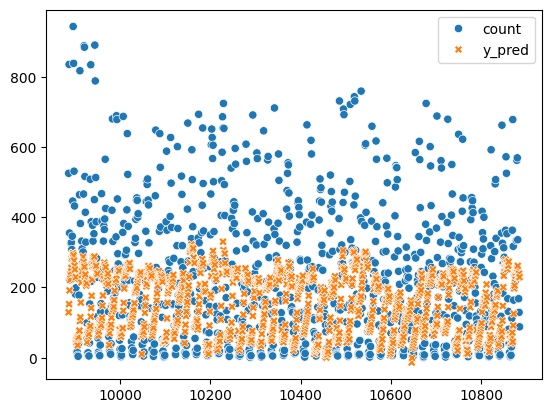

In [35]:
df1 = pd.DataFrame(y_test)

df1['y_pred'] = SGD.predict(x_test_scaled)
sns.scatterplot(df1);

# Случайный лес

Постройте модель случайного леса. Оцените качество предсказаний на обучающей и отложенной выборке.
Визуализируйте качество предсказаний, построив такие же scatter-диаграммы, которые были построены для
линейной модели.

In [41]:
RF=RandomForestRegressor(n_estimators=50)
RF.fit(x_train_scaled,y_train)
train_MAE = mean_absolute_error(y_train, RF.predict(x_train_scaled))
test_MAE = mean_absolute_error(y_test, RF.predict(x_test_scaled))
print('Cредняя абсолютная ошибка для обучающей выборки:', train_MAE)
print('Cредняя абсолютная ошибка для отложенной выборки:', test_MAE)

Cредняя абсолютная ошибка для обучающей выборки: 23.930656597111835
Cредняя абсолютная ошибка для отложенной выборки: 93.47698628571429


Визуализируем качество предсказаний для модели случайного леса.

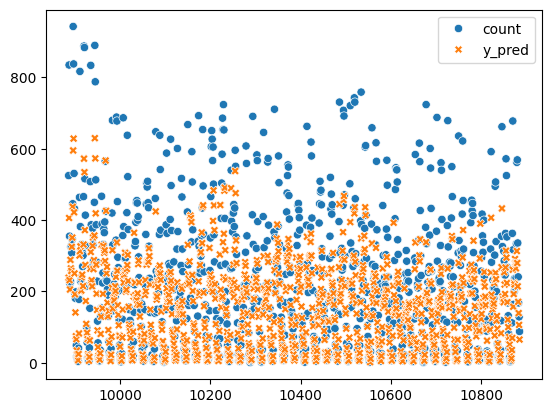

In [44]:
df1 = pd.DataFrame(y_test)

df1['y_pred'] = RF.predict(x_test_scaled)
sns.scatterplot(df1);

Построим нейронную сеть.

In [48]:
regr = MLPRegressor(random_state=1, activation='relu', max_iter=500).fit(x_train_scaled, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [49]:
train_MAE = mean_absolute_error(y_train, regr.predict(x_train_scaled))
test_MAE = mean_absolute_error(y_test, regr.predict(x_test_scaled))
print('Cредняя абсолютная ошибка для обучающей выборки:', train_MAE)
print('Cредняя абсолютная ошибка для отложенной выборки:', test_MAE)

Cредняя абсолютная ошибка для обучающей выборки: 83.40604726868585
Cредняя абсолютная ошибка для отложенной выборки: 101.56012044711801


Визуализируем качество предсказаний для построенной нейронной сети

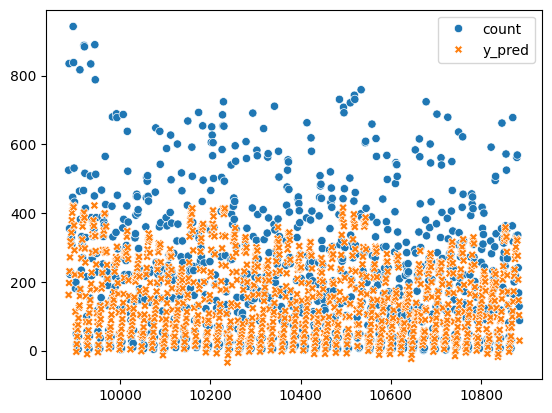

In [50]:
df1 = pd.DataFrame(y_test)

df1['y_pred'] = regr.predict(x_test_scaled)
sns.scatterplot(df1);